# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

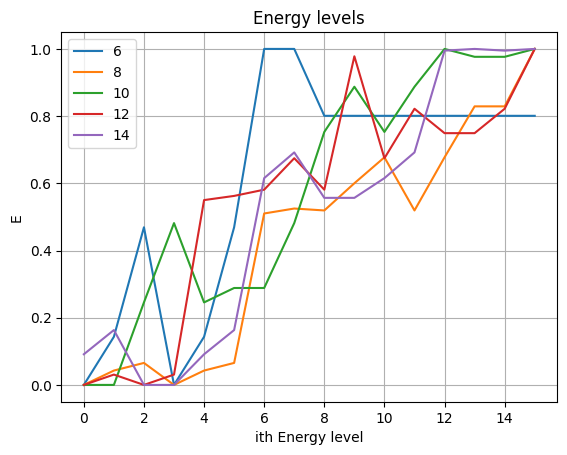

In [ ]:
from ed_utils import *

J = 0
h = 0
k_l = 1
k_r = k_l
eL = [6, 8, 10, 12, 14]

for L in eL:
    H = Ham(J, h, k_l, k_r, L)  # create the Hamiltonian
    N = 16  # number of energy levels
    E, psi = lg.eigsh(H, k=16, which='SA')
    psi0 = psi.T[0] # ground state
    E -= np.min(E)
    E /= np.abs(np.max(E) - np.min(E))
    
    # energy
    plt.plot(range(N), E, label=f"{L}")

    # magnetization profile
    # i = [i for i in range(L)]
    # mag = []
    # for site in i:
    #     mag.append(operator(site, X, psi0))
    
    # plt.plot([L for _ in range(L)], mag, label=f"{L}")

plt.title("Energy levels")
plt.xlabel("ith Energy level")
plt.ylabel("E")
plt.grid()
plt.legend()
plt.show()

# Reimplementation using QuSpin

In [31]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ed_utils import *

11it [00:04,  2.21it/s]


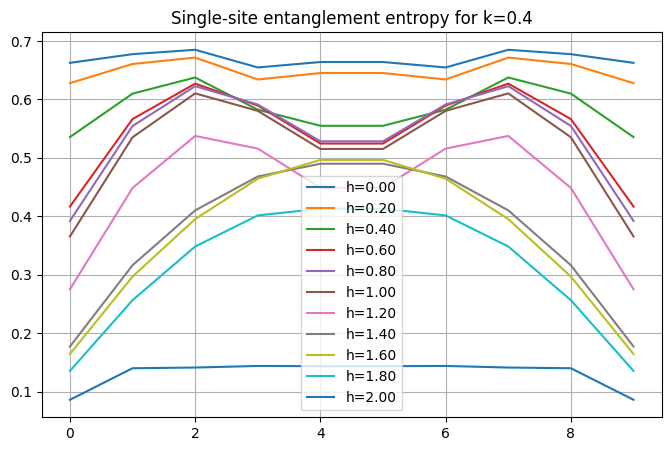

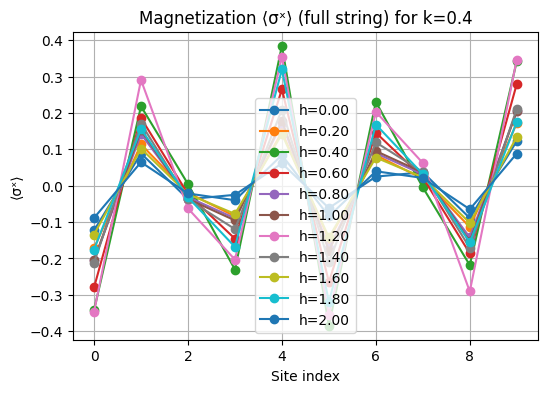

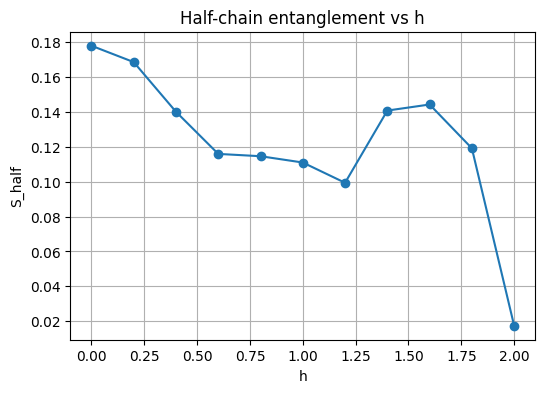

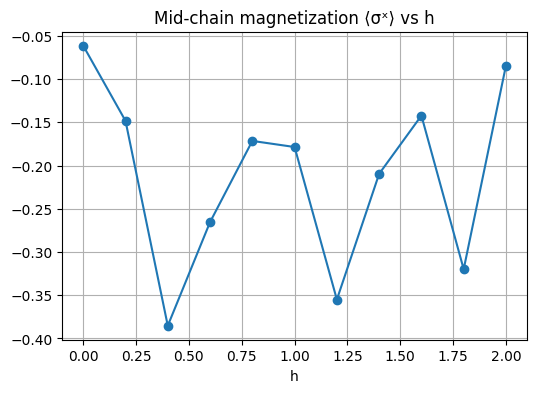

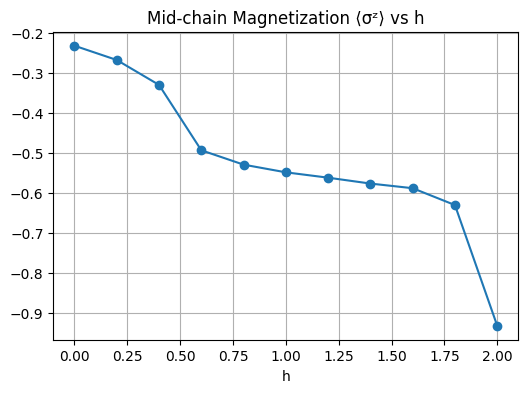

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 10
var_num = 11

basis = spin_basis_1d(L, pauli=1)

scan_var = "h"
opp = "k" if scan_var == "h" else "h"

J = 1
values = np.linspace(0, 2, var_num)
set = 0.4

single_site_entropy_curves = []
half_chain_entropy = []

mx_list = np.zeros((var_num, L))
my_list = np.zeros((var_num, L))
mz_list = np.zeros((var_num, L))

mz_mid_list=[]
my_mid_list=[]
mx_mid_list =[]

for ind, val in tqdm(enumerate(values)):

    # determine h and k
    if scan_var == "h":
        h = val
        k_l = k_r = set
    else:
        h = set     # fixed field, change if needed
        k_l = k_r = val

    # --- Hamiltonian ---
    # polarized boundary conditions
    strength = 1e-1
    pol_bc = [[strength, 0], [-1**L * strength, L-1]]

    J_term = [[J, i, i+1] for i in range(L-1)]   
    h_term = [[h, i] for i in range(L)]  

    xy_term = [[k_r, i, i+2] for i in range(L-2)]
    yx_term = [[-k_l, i, i+2] for i in range(L-2)]
    xyz_term = [[k_l, i, i+1, i+2] for i in range(L-2)]
    zyx_term = [[-k_r, i, i+1, i+2] for i in range(L-2)]

    static = [
        ["xx", J_term],
        ["z",  h_term],
        ["x", pol_bc],
        ["xy", xy_term],
        ["yx", yx_term],
        ["xyz", xyz_term],
        ["zyx", zyx_term]
    ]

    H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)
    E, V = H.eigh()
    psi = V[:, 0]  # ground state

    # --- Single-site entanglement ---
    s_sites = []
    for i in range(L):
        ent = basis.ent_entropy(psi, sub_sys_A=[i])
        s_sites.append(ent["Sent_A"])
    single_site_entropy_curves.append(s_sites)

    # --- string measurements ---
    mx_list[ind] = magnetization_string('x', psi, basis)
    my_list[ind] = magnetization_string('y', psi, basis)
    mz_list[ind] = magnetization_string('z', psi, basis)

    # --- mid-chain measurements ---
    mz_mid_list.append(magnetization_site('z', L//2, psi, basis))
    my_mid_list.append(magnetization_site('y', L//2, psi, basis))
    mx_mid_list.append(magnetization_site('x', L//2, psi, basis))

    # --- Half-chain EE ---
    mid = list(range(L//2))
    ent_mid = basis.ent_entropy(psi, sub_sys_A=mid)["Sent_A"]
    half_chain_entropy.append(ent_mid)

# ---- plotting ----
plt.figure(figsize=(8,5))
for i, v in enumerate(values):
    plt.plot(single_site_entropy_curves[i], label=f"{scan_var}={v:.2f}")
plt.title(f"Single-site entanglement entropy for {opp}={set}")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(values, half_chain_entropy, "-o")
plt.title(f"Half-chain entanglement vs {scan_var}")
plt.xlabel(f"{scan_var}")
plt.ylabel("S_half")
plt.grid()
plt.show()

# --- string magnetization ----
plot_string('X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string('Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string('Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

# --- site magnetization ---
plot_site('X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site('Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site('Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)

## Entanglement Entropy

## Magnetization

## Correlation 